In [8]:
from google.colab import files
uploaded = files.upload()

Saving Initial Public Offering 00.csv to Initial Public Offering 00 (2).csv


In [9]:
import pandas as pd
import io

df = pd.read_csv(
    io.BytesIO(list(uploaded.values())[0]),
    encoding='latin1'  # this fixes the unicode error
)
df.head()

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,...,CMP(NSE),Current Gains,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,08-06-2025,M & B Engineering Ltd,650,36.72,38.24,32.55,36.20,385,386,0.26,...,426.15,10.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,08-06-2025,Sri Lotus Developers & Realty Ltd,792,163.90,57.71,20.28,69.14,150,179.1,19.40,...,199.72,34.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,08-06-2025,National Securities Depository Ltd (NSDL),"4,011.60",103.97,34.98,7.73,41.01,800,880,10.00,...,61.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,08-05-2025,Aditya Infotech Ltd,"1,300",133.21,72.00,50.87,100.69,675,"1,018.00",50.81,...,"1,062.70",57.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,08-05-2025,Laxmi India Finance Ltd,254.26,1.30,1.84,2.22,1.87,158,136,-13.92,...,150,-5.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Clean unnamed columns
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

# Clean column names (remove spaces)
df.columns = df.columns.str.strip()

# Convert numeric columns
df['Listing Gain'] = pd.to_numeric(df['Listing Gain'], errors='coerce')
df['Current Gains'] = pd.to_numeric(df['Current Gains'], errors='coerce')
df['Issue_Size(crores)'] = pd.to_numeric(
    df['Issue_Size(crores)'].astype(str).str.replace(',',''),
    errors='coerce'
)
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

# Convert date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

print(df.shape)
df.head()

(561, 14)


,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains,Year
0,2025-08-06,M & B Engineering Ltd,650.00,36.72,38.24,32.55,36.20,385,386,0.26,426.85,426.15,10.87,2025.0
1,2025-08-06,Sri Lotus Developers & Realty Ltd,792.00,163.90,57.71,20.28,69.14,150,179.1,19.40,201.1,199.72,34.07,2025.0
2,2025-08-06,National Securities Depository Ltd (NSDL),4011.60,103.97,34.98,7.73,41.01,800,880,10.00,"1,294.05",61.76,NaN,2025.0
3,2025-08-05,Aditya Infotech Ltd,1300.00,133.21,72.00,50.87,100.69,675,"1,018.00",50.81,"1,064.60","1,062.70",57.72,2025.0
4,2025-08-05,Laxmi India Finance Ltd,254.26,1.30,1.84,2.22,1.87,158,136,-13.92,149,150,-5.70,2025.0


/tmp/ipykernel_17479/1647156406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Listing Gain', y='IPO_Name', data=top10, palette='viridis')


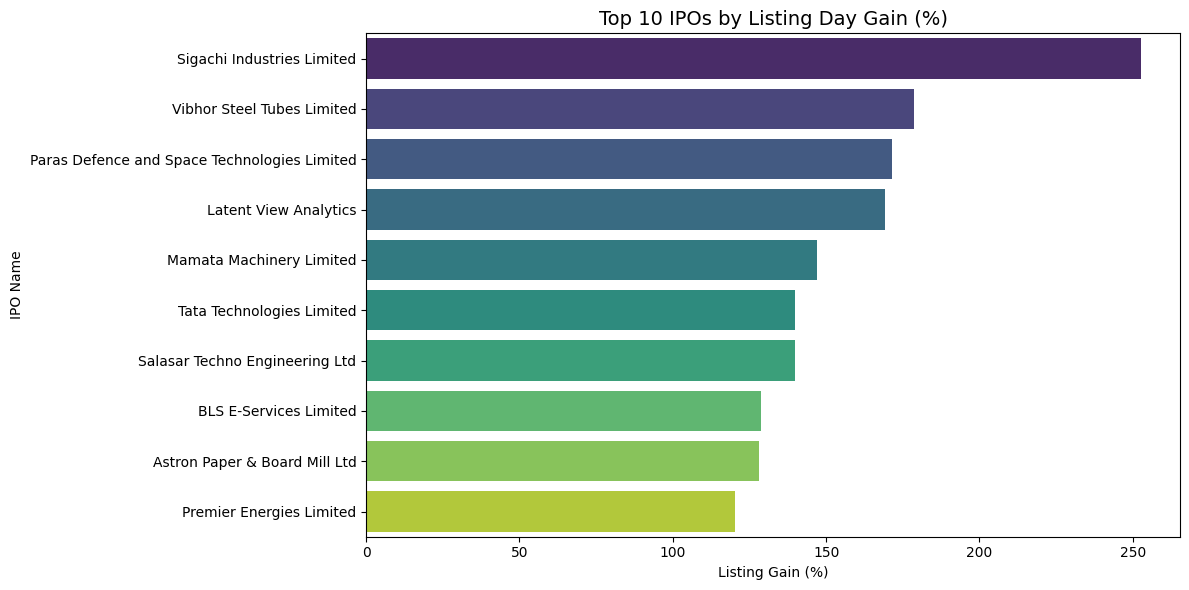

In [11]:
plt.figure(figsize=(12,6))
top10 = df.nlargest(10, 'Listing Gain')
sns.barplot(x='Listing Gain', y='IPO_Name', data=top10, palette='viridis')
plt.title('Top 10 IPOs by Listing Day Gain (%)', fontsize=14)
plt.xlabel('Listing Gain (%)')
plt.ylabel('IPO Name')
plt.tight_layout()
plt.show()



*  Sigachi Industries gave the highest listing day gain - likely a pharmaceutical/chemical company that was massively underpriced

*   Paras Defence & Space Technologies - defence sector IPO showing strong debut, interesting given India's defence push

*  Mix of sectors in top 10 - like: manufacturing, tech, services






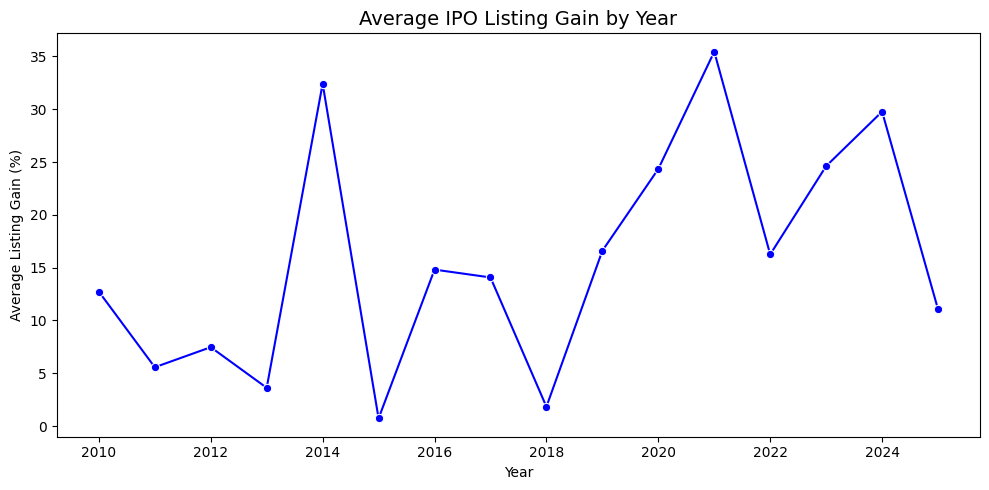

In [12]:
plt.figure(figsize=(10,5))
yearly = df.groupby('Year')['Listing Gain'].mean().reset_index()
sns.lineplot(x='Year', y='Listing Gain', data=yearly, marker='o', color='blue')
plt.title('Average IPO Listing Gain by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Listing Gain (%)')
plt.tight_layout()
plt.show()



*   2014 peak - IPO market was booming, Modi government's first year, investor sentiment was very high

*   2016-2017 crash - Demonetization effect! IPO market took a massive hit

* 2018 bottom - Worst year for IPO investors in this dataset

*  2021-2022 surge - Post COVID bull run, massive IPO boom (Zomato, Paytm era)


*  2025 dip - Market cooling down currently



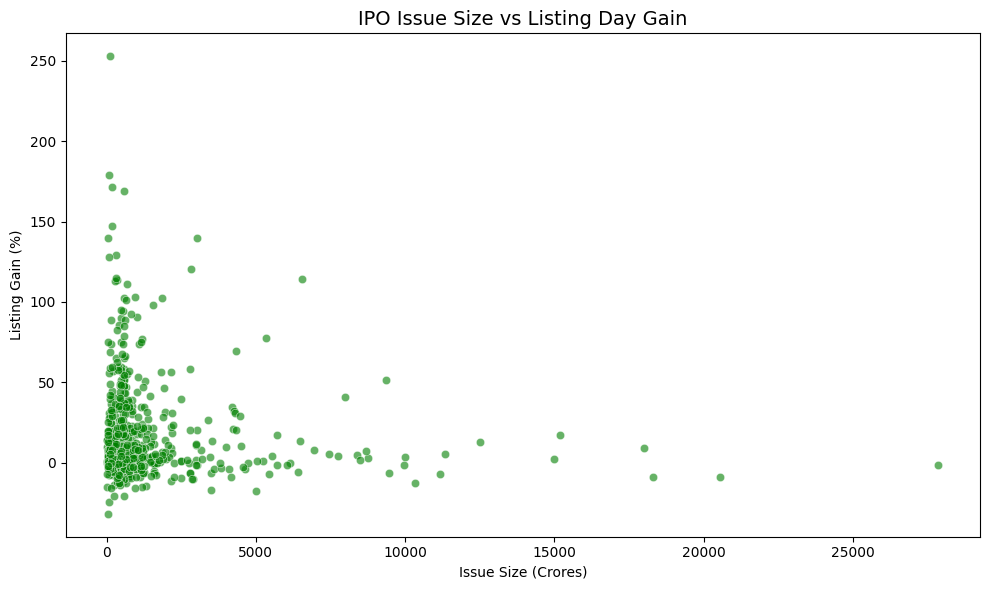

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Issue_Size(crores)',
    y='Listing Gain',
    data=df,
    alpha=0.6,
    color='green'
)
plt.title('IPO Issue Size vs Listing Day Gain', fontsize=14)
plt.xlabel('Issue Size (Crores)')
plt.ylabel('Listing Gain (%)')
plt.tight_layout()
plt.show()



*   Small IPOs (below ₹500 Cr) - scattered everywhere, high variance, some giving 150-250% gains!

* Large IPOs (above ₹2000 Cr) - all clustered near 0-50% gains, very predictable and boring

*   Sweet spot - Small to mid size IPOs give the best listing day returns

**Business Insight:** Smaller IPOs are riskier but offer significantly higher listing day gains. Large IPOs (megacap) tend to list closer to their offer price.



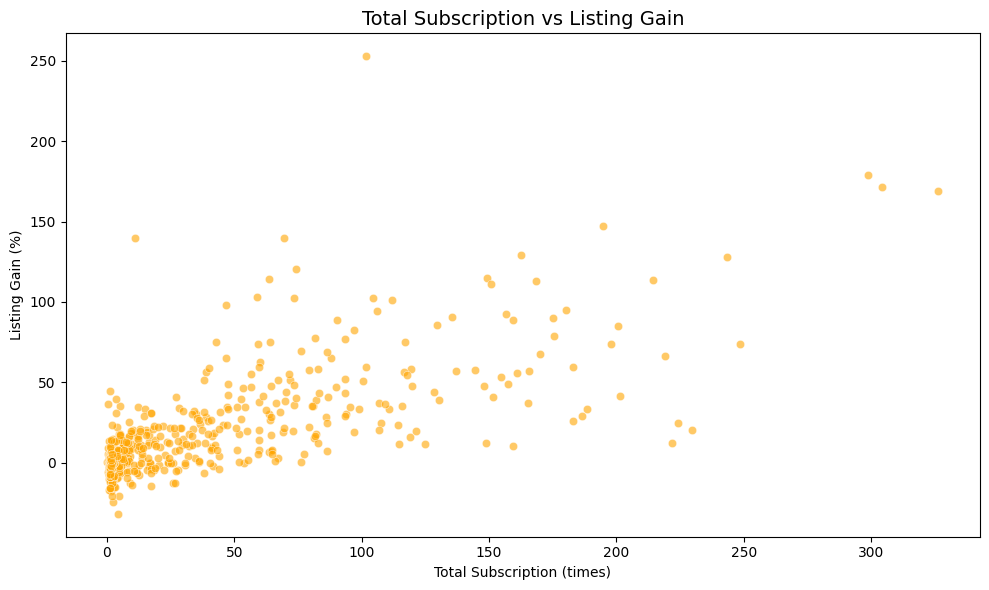

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Total',
    y='Listing Gain',
    data=df,
    alpha=0.6,
    color='orange'
)
plt.title('Total Subscription vs Listing Gain', fontsize=14)
plt.xlabel('Total Subscription (times)')
plt.ylabel('Listing Gain (%)')
plt.tight_layout()
plt.show()



*   Low subscription (0-50x) - most IPOs cluster here with modest gains

*   High subscription (150x+) - actually shows HIGHER listing gains! The two outliers at 250x+ subscription gave 150-170% listing gains

*   Clear positive trend - more oversubscribed = better listing day performance

**Business Insight:** Subscription rate is a strong signal for listing day performance - heavily oversubscribed IPOs consistently deliver higher gains. Retail investors should track QIB subscription as a key indicator.



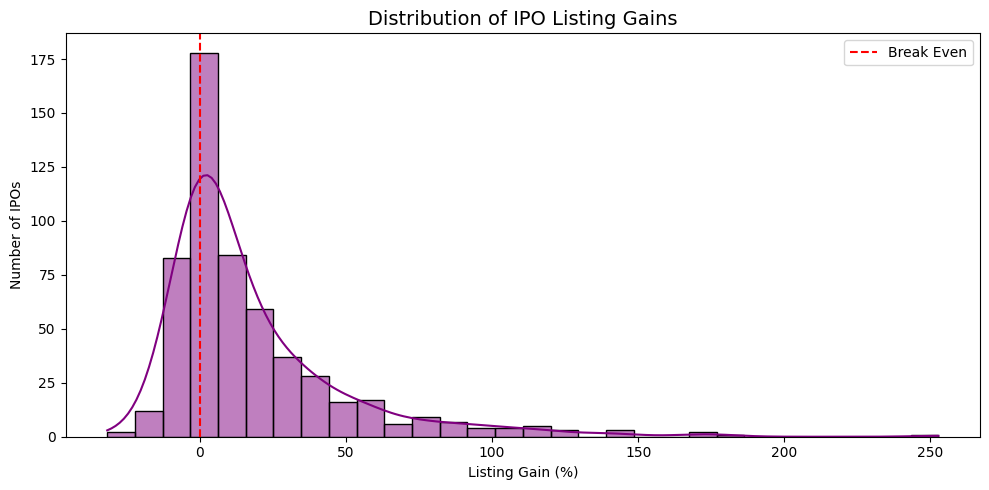

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df['Listing Gain'].dropna(), bins=30, kde=True, color='purple')
plt.title('Distribution of IPO Listing Gains', fontsize=14)
plt.xlabel('Listing Gain (%)')
plt.ylabel('Number of IPOs')
plt.axvline(x=0, color='red', linestyle='--', label='Break Even')
plt.legend()
plt.tight_layout()
plt.show()



*   Peak is just above 0% — most IPOs give modest 0-20% listing gains

*   Right skewed distribution - a few exceptional IPOs pull the average up significantly


*   Very few negative listings - majority of IPOs list above offer price, good sign for investors

*   Long tail to the right - rare but massive gainers (150-250%) exist


**Business Insight:** While most IPOs deliver modest listing gains, the distribution is positively skewed - meaning exceptional gainers are more common than exceptional losers. IPO investing as a strategy has a favorable risk-reward profile.
